# **REVERSE IMAGE SEARCH ENGINE - SIMILARITY SEARCH**

# IMPORTS

In [8]:
import numpy as np
import os
import random
from sklearn.neighbors import NearestNeighbors
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle
from sklearn.decomposition import PCA

# UTILITIES

In [9]:
def extract_classname_filename(str):
    return str.split('/')[-2] + '/' + str.split('/')[-1]

def plot_images(filenames, distances):
    images = []
    for filename in filenames:
        images.append(mpimg.imread(filename))
    plt.figure(figsize=(12, 10))
    columns = 4
    for i, image in enumerate(images):
        ax = plt.subplot(int(len(images) / columns + 1), columns, i + 1)
        if i == 0:
            ax.set_title("Query Image\n" + extract_classname_filename(filenames[i]))
        else:
            ax.set_title("Similar Image\n" + extract_classname_filename(filenames[i]) + "\nDistance: " + str(float("{0:.2f}".format(distances[i]))))
        plt.axis('off')
        plt.imshow(image)

In [10]:
def apply_knn(features, n=5, metric='cosine'):
  knn = NearestNeighbors(n_neighbors=n, metric=metric).fit(features)
  distances, indices = knn.kneighbors(features)
  return knn, distances, indices

In [11]:
def evaluate_knn_retrieval(features_compressed, class_ids, knn_model, k=5):
    precisions = []
    recalls = []

    for i in range(len(features_compressed)):
        query_label = class_ids[i]
        distances, indices = knn_model.kneighbors([features_compressed[i]], n_neighbors=k+1)

        retrieved_indices = indices[0][1:]
        retrieved_labels = class_ids[retrieved_indices]

        relevant = sum(retrieved_labels == query_label)
        precision = relevant / k

        total_relevant = np.sum(class_ids == query_label) - 1
        recall = relevant / total_relevant if total_relevant > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    return avg_precision, avg_recall

# LOADING SAVED FEATURES, FILENAMES & CLASS IDS

In [12]:
features = np.load("../features_data/features.npy")
filenames = np.load("../features_data/filenames.npy", allow_pickle=True)
class_ids = np.load("../features_data/class_ids.npy")

print("Features:", features.shape)
print("Filenames:", len(filenames))
print("Class IDs:", len(class_ids))

num_images = 8677

Features: (8677, 2048)
Filenames: 8677
Class IDs: 8677


# SIMILARITY SEARCH USING EUCLIDEAN DISTANCE

In [14]:
n = 11
knn_euc, distances, indices = apply_knn(features, n=n, metric='euclidean')

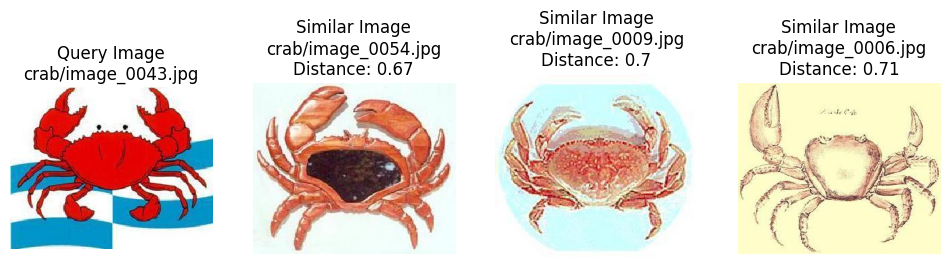

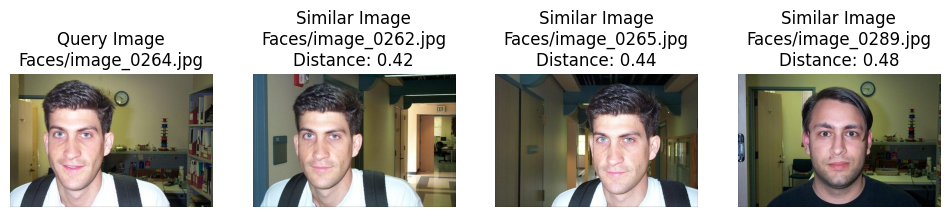

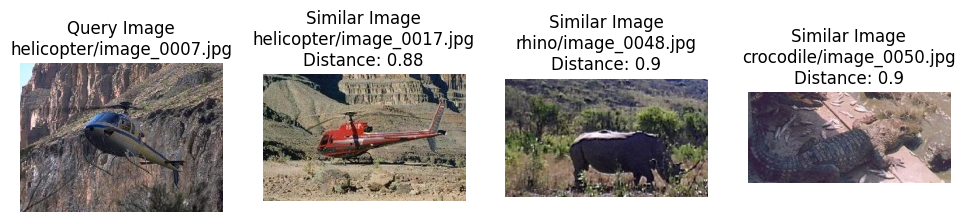

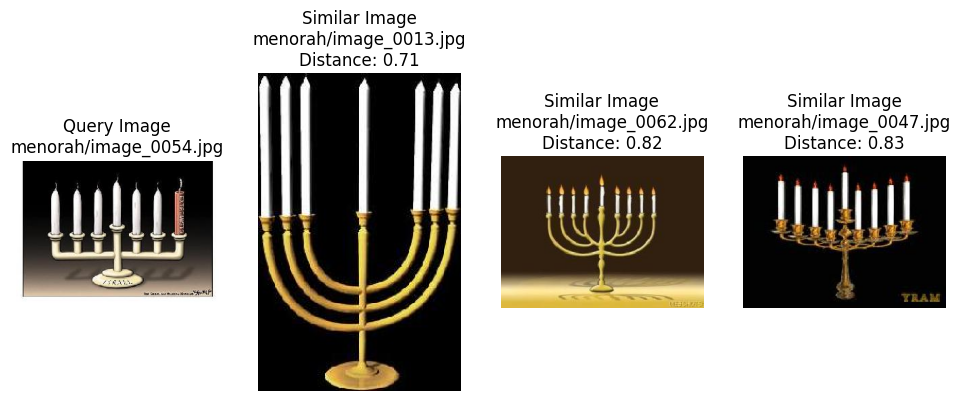

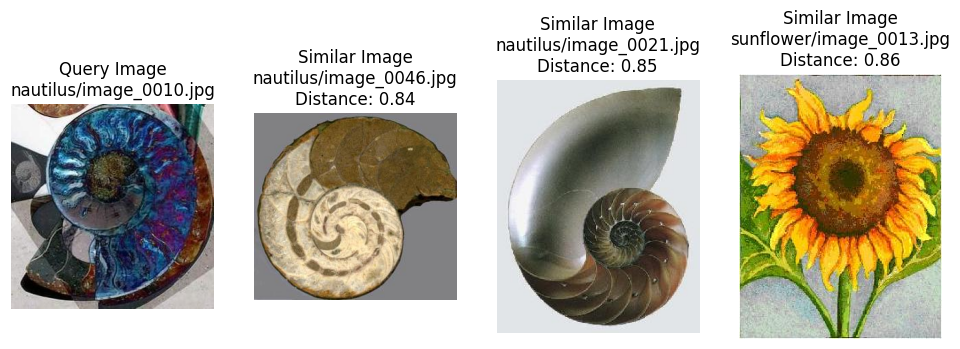

In [15]:
for _ in range(5):
    random_image_index = random.randint(0, num_images)
    distances, indices = knn_euc.kneighbors(
        [features[random_image_index]]
    )
    similar_image_paths = [filenames[random_image_index]] + \
        [filenames[indices[0][i]] for i in range(1, 4)]
    plot_images(similar_image_paths, distances[0])

# SIMILARITY SEARCH USING COSINE SIMILARITY

In [17]:
n = 11
knn_cos, distances, indices = apply_knn(features, n=n, metric='cosine')

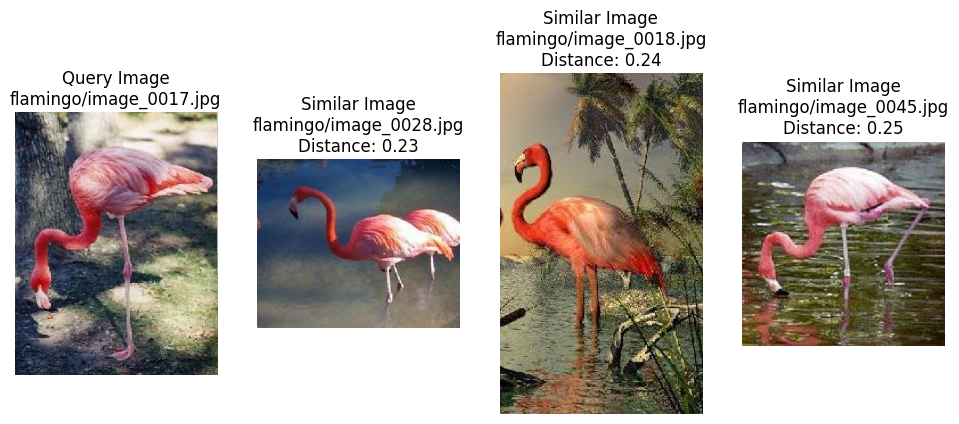

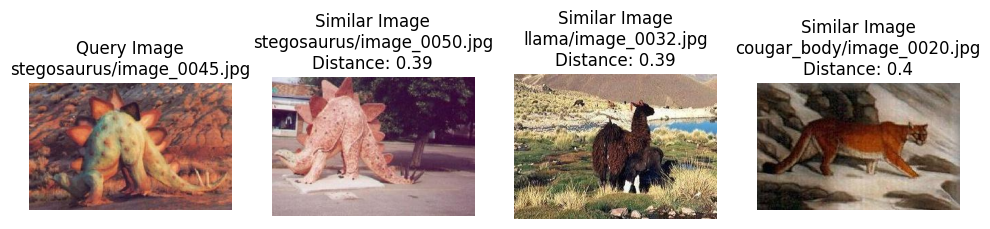

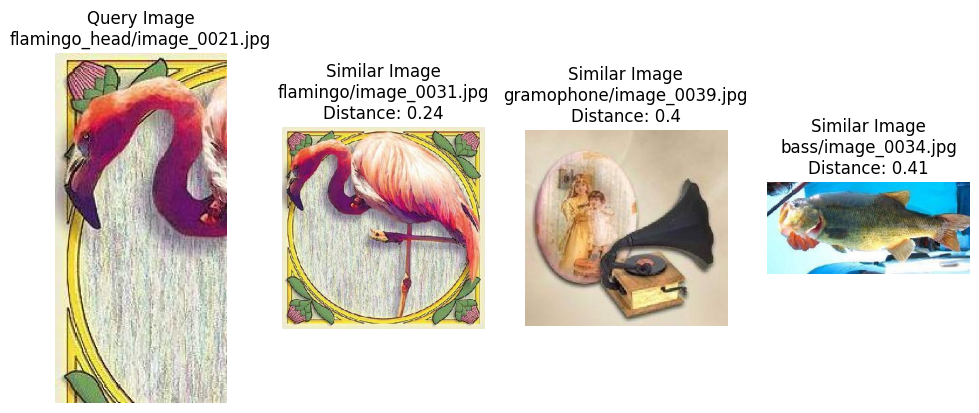

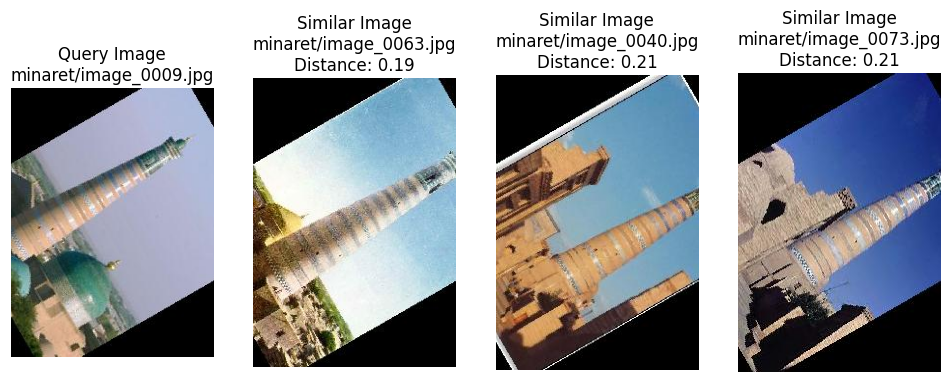

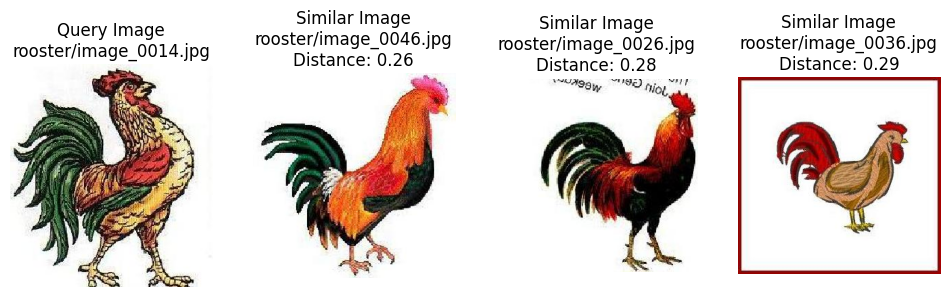

In [18]:
for _ in range(5):
    random_image_index = random.randint(0, num_images)
    distances, indices = knn_cos.kneighbors(
        [features[random_image_index]]
    )
    similar_image_paths = [filenames[random_image_index]] + \
        [filenames[indices[0][i]] for i in range(1, 4)]
    plot_images(similar_image_paths, distances[0])

# DIMENSIONALITY REDUCTION

Reason: to speed up search on large datasets and improve quality by removing noise and keeping only important features.

In [11]:
num_feature_dimensions = 100
pca = PCA(n_components=num_feature_dimensions)
pca.fit(features)
feature_list_compressed = pca.transform(features)

# SIMILARITY SEARCH AFTER DIMENSIONALITY REDUCTION USING EUCLIDEAN DISTANCE

In [1]:
knn_euc_pca, distances, indices = apply_knn(feature_list_compressed, n=n, metric='euclidean')

NameError: name 'apply_knn' is not defined

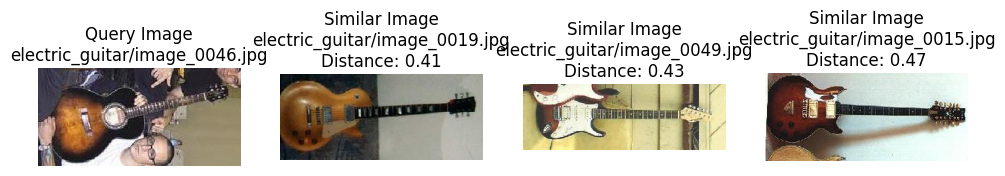

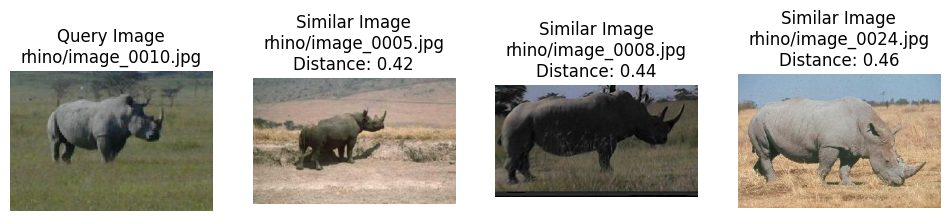

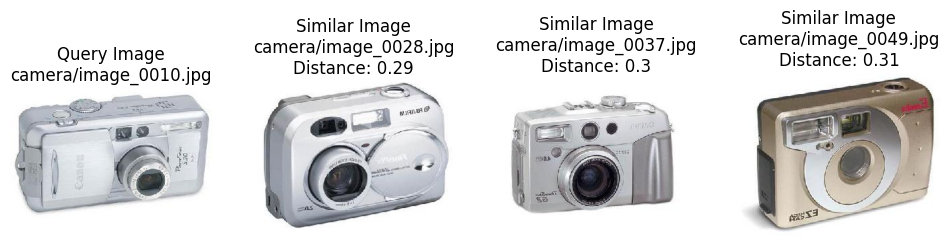

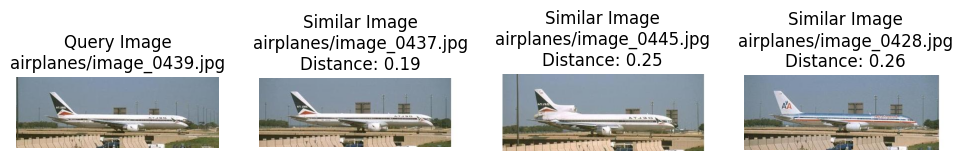

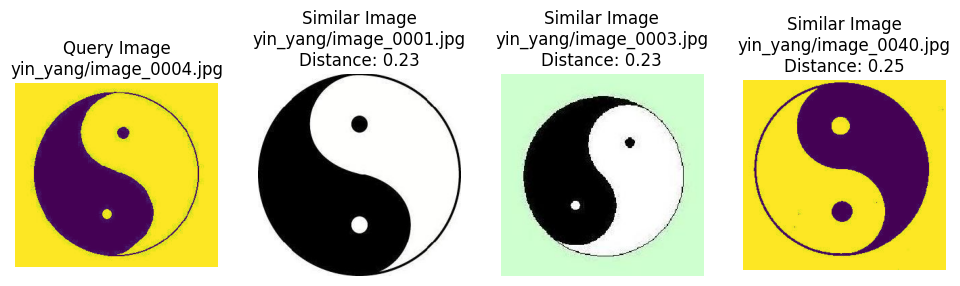

In [20]:
for i in range(5):
    random_image_index = random.randint(0, num_images)
    distances, indices = knn_euc_pca.kneighbors(
        [feature_list_compressed[random_image_index]])
    similar_image_paths = [filenames[random_image_index]] + \
        [filenames[indices[0][i]] for i in range(1, 4)]
    plot_images(similar_image_paths, distances[0])

# SIMILARITY SEARCH AFTER DIMENSIONALITY REDUCTION USING COSINE SIMILARITY

In [22]:
knn_cos_pca, distances, indices = apply_knn(feature_list_compressed, n=n, metric='cosine')

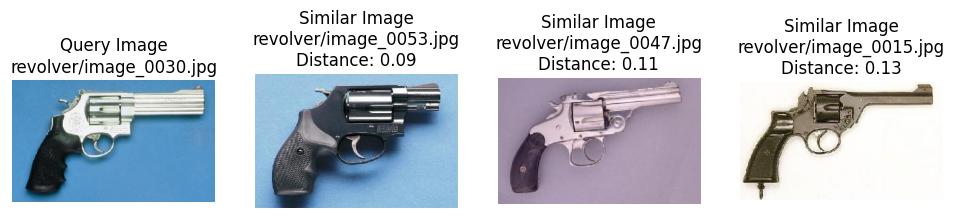

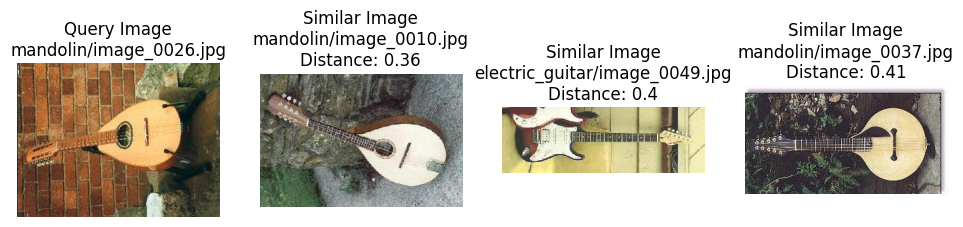

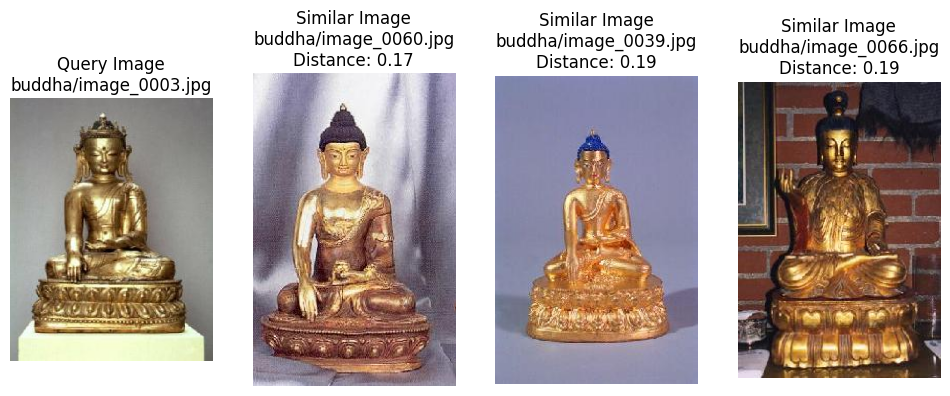

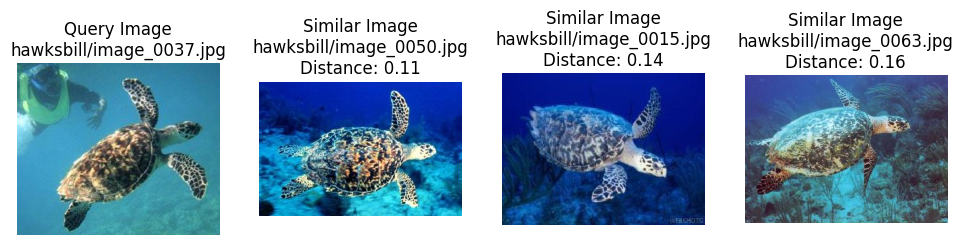

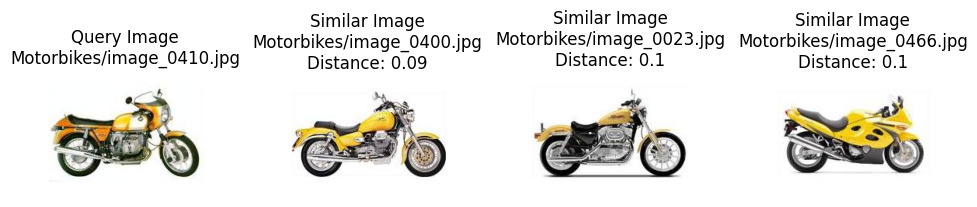

In [23]:
for i in range(5):
    random_image_index = random.randint(0, num_images)
    distances, indices = knn_cos_pca.kneighbors(
        [feature_list_compressed[random_image_index]])
    similar_image_paths = [filenames[random_image_index]] + \
        [filenames[indices[0][i]] for i in range(1, 4)]
    plot_images(similar_image_paths, distances[0])

# PERFORMANCE EVALUATION

In [24]:
k = 100
avg_precision, avg_recall = evaluate_knn_retrieval(features, class_ids, knn_euc, k=k)
print("Similairty Search with Euclidean Distance")
print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Similairty Search with Euclidean Distance
Average Precision@100: 0.6020
Average Recall@100: 0.4942


In [25]:
avg_precision, avg_recall = evaluate_knn_retrieval(features, class_ids, knn_cos, k=k)
print("Similairty Search with Cosine Similarity")
print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Similairty Search with Cosine Similarity
Average Precision@100: 0.6020
Average Recall@100: 0.4942


In [27]:
avg_precision, avg_recall = evaluate_knn_retrieval(feature_list_compressed, class_ids, knn_euc_pca, k=k)
print("Similairty Search with Euclidean Distance after Dimensionality Reduction")
print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Similairty Search with Euclidean Distance after Dimensionality Reduction
Average Precision@100: 0.6175
Average Recall@100: 0.5104


In [28]:
avg_precision, avg_recall = evaluate_knn_retrieval(feature_list_compressed, class_ids, knn_cos_pca, k=k)
print("Similairty Search with Cosine Similarity after Dimensionality Reduction")
print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Similairty Search with Cosine Similarity after Dimensionality Reduction
Average Precision@100: 0.6175
Average Recall@100: 0.5104


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model


def define_model():
    base_model = ResNet50(include_top=False, input_shape=(img_width, img_height, 3), pooling='avg')
    for layer in base_model.layers:
        layer.trainable = False

    input_tensor = Input(shape=(img_width, img_height, 3))
    x = base_model(input_tensor)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    output_tensor = Dense(num_classes, activation='softmax')(x)

    full_model = Model(inputs=input_tensor, outputs=output_tensor)
    return full_model, base_model

In [14]:
def extract_features(img_path, feature_model):
    img = load_img(img_path, target_size=(img_width, img_height))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    features = feature_model.predict(img_array)
    flattened = features.flatten()
    normalized = flattened / norm(flattened)
    return normalized

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


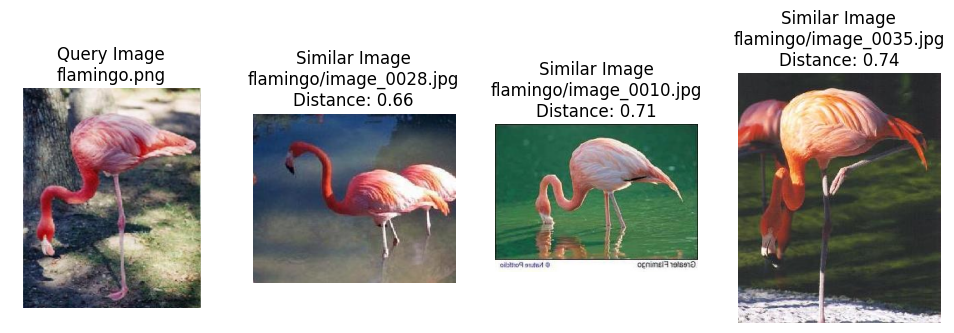

In [ ]:
from keras.applications.resnet50 import preprocess_input
from keras.utils import load_img, img_to_array
from numpy.linalg import norm


num_classes = 101
img_width, img_height = 224, 224
batch_size = 128


_, feature_extractor = define_model()

n = 11
knn_euc, distances, indices = apply_knn(features, n=n, metric='euclidean')

def extract_custom_image_feature(img_path):
    return extract_features(img_path, feature_extractor)

custom_image_path = 'flamingo.png' 

custom_feature = extract_custom_image_feature(custom_image_path).reshape(1, -1)

distances, indices = knn_euc.kneighbors(custom_feature)

similar_image_paths = [custom_image_path] + [filenames[i] for i in indices[0][1:4]]

plot_images(similar_image_paths, distances[0])


In [ ]:
project_root = os.path.dirname(os.getcwd())
old_prefix = "/content/caltech101/caltech-101/101_ObjectCategories"
# Your current local path
new_prefix = os.path.join(project_root, "data", "caltech101", "caltech-101", "101_ObjectCategories")

# Fix the paths in filenames
filenames = [filename.replace(old_prefix, new_prefix) for filename in filenames]


In [ ]:
def extract_classname_filename(path):
    parts = path.replace("\\", "/").split("/") 
    if len(parts) >= 2:
        return parts[-2] + '/' + parts[-1]
    else:
        return parts[-1] 